# Here we will train the residual model a.k.a model B

In [14]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score
from scipy.stats import spearmanr
from lightgbm import LGBMRegressor      # pip install lightgbm

data = pd.read_parquet('../data/processed/tracks_enriched.parquet')
target = 'popularity'

# ---- split ONCE; both stages use the same test set so it's never touched in training
train, test = train_test_split(data, test_size=0.2, random_state=42)

In [15]:
# ===== STAGE 1: context model — expected popularity from EXTERNAL advantages only =====
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict

ctx_features = ['artist_fame_loo', 'track_genre']
tr, te = train.copy(), test.copy()
tr['track_genre'] = tr['track_genre'].astype('category')
te['track_genre'] = te['track_genre'].astype('category')



param_grid = [{'n_estimators': [100, 200, 300], 'learning_rate': list(np.arange(0.02, 0.13, 0.03))}]
gs = GridSearchCV(estimator=LGBMRegressor(), 
                  param_grid=param_grid, 
                  scoring='r2', 
                  cv=10, 
                  n_jobs=1)

gs.fit(tr[ctx_features], tr[target], categorical_feature=['track_genre'])

best = LGBMRegressor(**gs.best_params_, random_state=667)

# TRAIN residuals — out-of-fold: every row predicted by a model that never trained on it
train_expected = cross_val_predict(best, tr[ctx_features], train[target], cv=10)
train_resid = train[target].values - train_expected

# TEST residuals — fit context on ALL of train, predict on unseen test (legitimately out-of-sample)
best.fit(tr[ctx_features], train[target])
test_resid = test[target].values - best.predict(te[ctx_features])

# attach to the split frames — this is what Model B actually consumes
train['residual'] = train_resid
test['residual']  = test_resid

# optional: also write into the combined frame for one EDA heatmap
data.loc[train.index, 'residual'] = train_resid
data.loc[test.index,  'residual'] = test_resid

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 285
[LightGBM] [Info] Number of data points in the train set: 51865, number of used features: 2
[LightGBM] [Info] Start training from score 36.759202
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 51865, number of used features: 2
[LightGBM] [Info] Start training from score 36.728526
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 283
[LightGBM] [Info] Number of data points in the train set: 51865, number of used features: 2
[LightGBM] [Info] Start trainin

In [16]:
print(gs.best_score_)
print(gs.best_params_)

0.7392646088360935
{'learning_rate': np.float64(0.11000000000000001), 'n_estimators': 300}


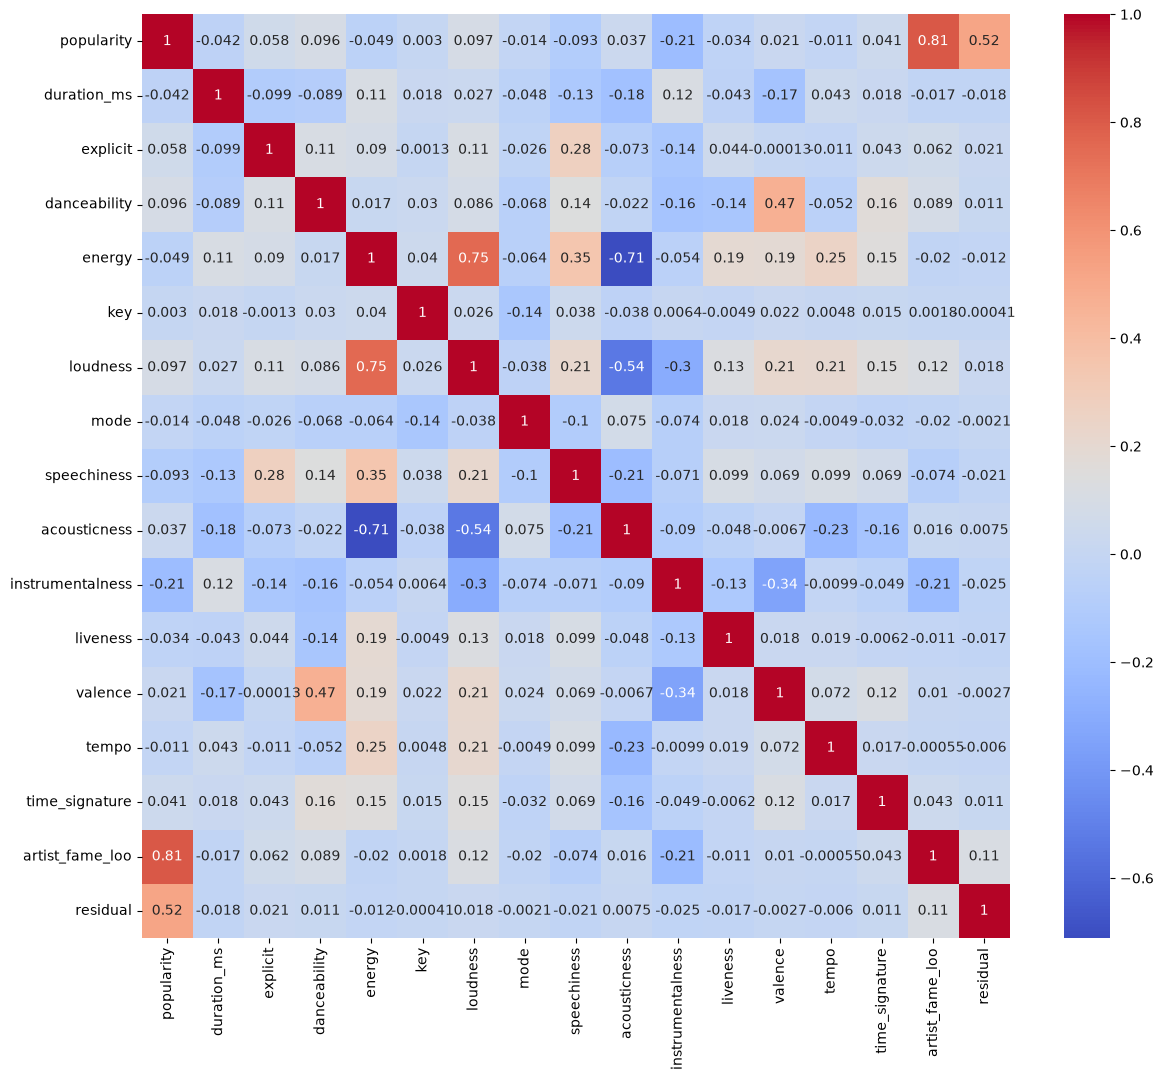

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = data.corr(numeric_only=True, method='spearman')
plt.figure(figsize=(14, 12)) 
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [18]:
# ===== STAGE 2: Model B — predict the residual from AUDIO only =====
audio = ['danceability','energy','key','loudness','mode','speechiness',
         'acousticness','instrumentalness','liveness','valence','tempo',
         'time_signature','duration_ms','explicit']

gs_b = GridSearchCV(estimator=LGBMRegressor(), 
                  param_grid=param_grid, 
                  scoring='r2', 
                  cv=10, 
                  n_jobs=1)

gs_b.fit(tr[ctx_features], tr[target], categorical_feature=['track_genre'])

model_b = LGBMRegressor(**gs_b.best_params_, random_state=667, importance_type='gain')
model_b.fit(train[audio], train_resid)

pred = model_b.predict(test[audio])
print("R²:      ", r2_score(test_resid, pred))
print("MAE:     ", mean_absolute_error(test_resid, pred))
print("Spearman:", spearmanr(test_resid, pred).correlation)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 285
[LightGBM] [Info] Number of data points in the train set: 51865, number of used features: 2
[LightGBM] [Info] Start training from score 36.759202
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 51865, number of used features: 2
[LightGBM] [Info] Start training from score 36.728526
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 283
[LightGBM] [Info] Number of data points in the train set: 51865, number of used features: 2
[LightGBM] [Info] Start trainin

In [19]:
import numpy as np

def precision_at_k(y_true, y_pred, k=50, top_frac=0.10):
    # "actually good" = real residual in the top top_frac of the test set
    threshold = np.quantile(y_true, 1 - top_frac)
    top_k_idx = np.argsort(y_pred)[-k:]          # the model's K highest-scored songs
    hits = (np.asarray(y_true)[top_k_idx] >= threshold).sum()
    return hits / k

for k in (20, 50, 100, 200, 500, 1000, 10000, 100_000):
    print(f"Precision@{k}: {precision_at_k(test_resid, pred, k=k):.2%}")

Precision@20: 20.00%
Precision@50: 16.00%
Precision@100: 14.00%
Precision@200: 16.50%
Precision@500: 13.80%
Precision@1000: 13.10%
Precision@10000: 10.82%
Precision@100000: 1.44%


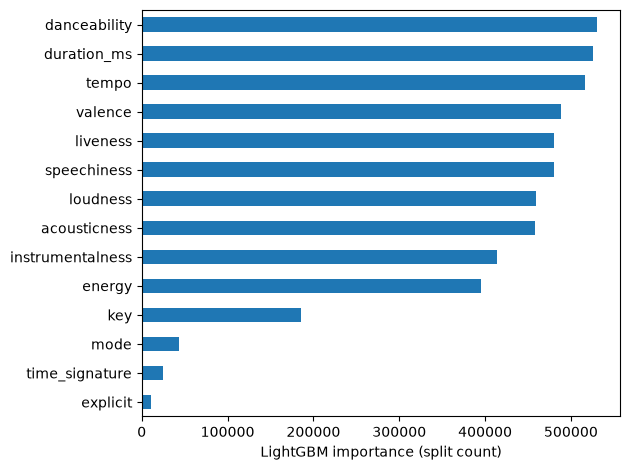

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.Series(model_b.feature_importances_, index=audio).sort_values()
imp.plot.barh()
plt.xlabel("LightGBM importance (split count)")
plt.tight_layout(); plt.show()

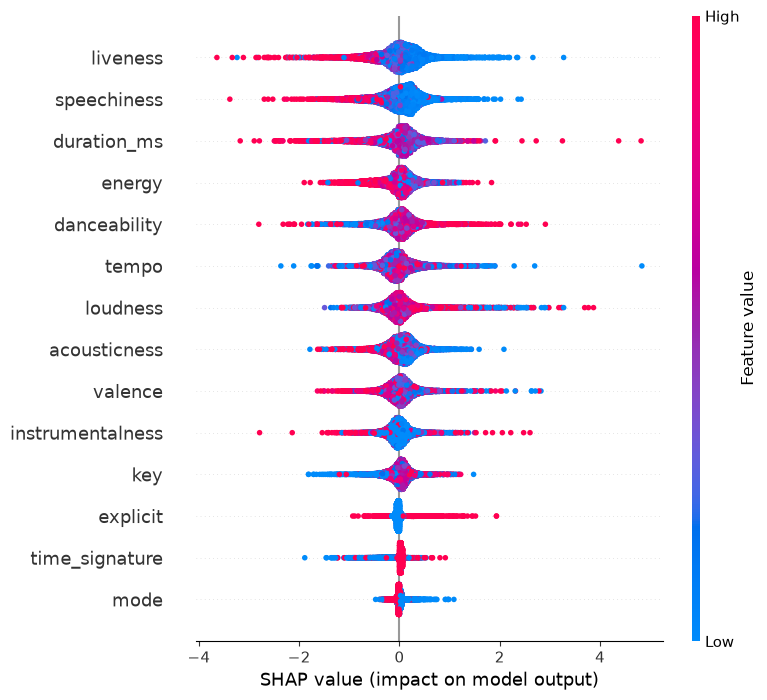

In [21]:
import shap
explainer = shap.TreeExplainer(model_b)
sv = explainer.shap_values(test[audio])
shap.summary_plot(sv, test[audio], feature_names=audio)

In [22]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model_el = make_pipeline(
    StandardScaler(),                      # required — see below
    ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],  # mixes to try
        cv=5,
        n_jobs=-1,
    )
)
model_el.fit(train[audio], train_resid)

en = model_el.named_steps['elasticnetcv']
print('best alpha:', en.alpha_, 'best l1_ratio:', en.l1_ratio_)
print('nonzero coefs:', (en.coef_ != 0).sum(), 'of', len(en.coef_))

best alpha: 0.051710817828160935 best l1_ratio: 0.1
nonzero coefs: 12 of 14


In [23]:
pred_el = model_el.predict(test[audio])
print("R²:      ", r2_score(test_resid, pred_el))
print("MAE:     ", mean_absolute_error(test_resid, pred_el))
print("Spearman:", spearmanr(test_resid, pred_el).correlation)

R²:       0.000484116711450322
MAE:      6.077453524464638
Spearman: 0.02388706579733232
